# E-commerce Funnel and Behaviour Analysis

Technical notebook supporting the portfolio case study. It reconstructs a five-stage customer funnel, calculates stage-level drop-off, and compares behaviour across device, time, referral source and geography.

**Environment note:** This notebook was originally developed in Google Colab. Upload and download cells may require Colab, while the analysis logic is standard Python/SQL.


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Triggers the upload dialog

file_name = list(uploaded.keys())[0]
print("Uploaded:", file_name)

# Auto-detect file type and load
if file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

df.head()

In [ ]:
import sqlite3
import pandas as pd

# Create in-memory database
conn = sqlite3.connect(":memory:")

# Push dataframe into SQL table, recreating it to include new columns like 'Continent'
df.to_sql("mytable", conn, index=False, if_exists="replace")

# SQL query
query = """
SELECT PageType, COUNT(*) AS count
FROM mytable
GROUP BY PageType
"""

result = pd.read_sql_query(query, conn)
result

,PageType,count
0,cart,1599
1,checkout,1123
2,confirmation,1010
3,home,5000
4,product_page,3987



drop-off rate calculation
A = nr users at step A
B = nr users at step B
numeric:
drop_off_rate = (A - B) / A
in percentages:
drop_off_pct = ((A - B) / A) * 100

In [ ]:
#home->product_page
dropOff=(5000-3987)/5000
print(f"{dropOff*100}%")





20.26%


In [ ]:
#product_page->cart



dropOff=(3987-1599)/3987
print(f"{dropOff*100}%")





59.89465763732129%


since biggest drop off is on the product page, lets see how long users spend here on avearge.

In [ ]:
#query for avg time spent on pages
query = """
select pageType, avg (TimeOnPage_seconds) as avgTimeOnPage
from mytable
group by pageType
"""
result=pd.read_sql_query(query,conn)
result

,PageType,avgTimeOnPage
0,cart,98.743590
1,checkout,96.606411
2,confirmation,95.922772
3,home,97.790800
4,product_page,97.057186


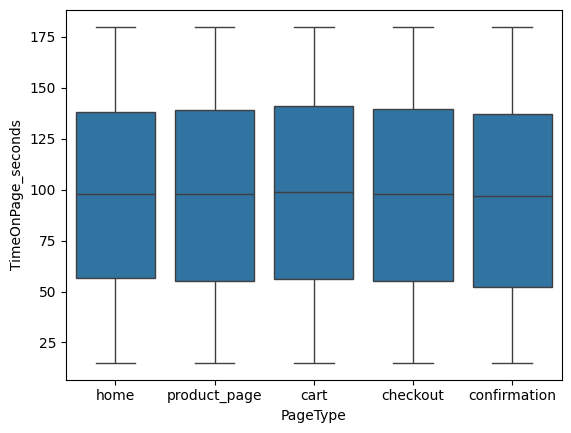

In [ ]:
#time on page boxplots
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df['PageType'], y=df['TimeOnPage_seconds'])
plt.show()


In [ ]:
#cart->checkout



dropOff=(1599-1123)/1599
print(f"{dropOff*100}%")





29.768605378361475%


In [ ]:
#checkout->comfirmatiom

dropOff=(1123-1010)/1123
print(f"{dropOff*100}%")


10.062333036509349%


In [ ]:
# segmentation by device type

#query
query = """
SELECT DeviceType, count(*) as count
from mytable
group by DeviceType
"""
result=pd.read_sql_query(query,conn)
result



,DeviceType,count
0,Desktop,4240
1,Mobile,4256
2,Tablet,4223


from matplotlib import pyplot as plt
_df_4['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_5.groupby('DeviceType').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_6['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_7['DeviceType'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_7, x='count', y='DeviceType', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
query = """
SELECT DeviceType, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY DeviceType
"""
result=pd.read_sql_query(query,conn)
result

,DeviceType,unique_purchases
0,Desktop,339
1,Mobile,337
2,Tablet,334


In [ ]:
#total unique purchases query
query = """
SELECT COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
"""
result=pd.read_sql_query(query,conn)
result

,unique_purchases
0,1010


In [ ]:
#segment unique purchases by Referral Source
query = """
select referralsource, count(DISTINCT sessionID||userID) as count
from mytable
where Purchased = 1
group by referralsource
"""
result=pd.read_sql_query(query,conn)
result


,ReferralSource,count
0,Direct,243
1,Email,251
2,Google,277
3,Social Media,239


from matplotlib import pyplot as plt
_df_0['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('ReferralSource').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_3['ReferralSource'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_3, x='count', y='ReferralSource', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
#conversion rate

total_on_homepage = 5000
total_unique_purchases = 1010

conversion_rate = (total_unique_purchases / total_on_homepage) * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 20.20%


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [ ]:
df['Purchased'] = df['Purchased'].fillna(0).astype(int)
df['ItemsInCart'] = df['ItemsInCart'].fillna(0).astype(int)

In [ ]:
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

In [ ]:
df['HighIntent'] = (df['ItemsInCart'] > 0).astype(int)

In [ ]:
import numpy as np
df['EngagementScore'] = (
    df['TimeOnPage_seconds'].clip(lower=1).apply(np.log)
)

In [ ]:
df['IsProductPage'] = (df['PageType'] == 'product_page').astype(int)
df['IsHome'] = (df['PageType'] == 'home').astype(int)

In [ ]:
df['Hour'] = df['Timestamp'].dt.hour
df['IsEvening'] = df['Hour'].between(18, 23).astype(int)

#time of dag

In [ ]:
!pip install pycountry-convert
import pycountry_convert as pc

# Initialize a list to store unmapped countries
unmapped_countries_list = []

def country_to_continent(country_name):
    if country_name == 'UK':
        return 'Europe'
    try:
        country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return {
            'AF': 'Africa',
            'EU': 'Europe',
            'AS': 'Asia',
            'NA': 'North America',
            'SA': 'South America',
            'OC': 'Oceania'
        }[continent_code]
    except Exception: # Catch all exceptions during conversion
        # Only add to list if not already present
        if country_name not in unmapped_countries_list:
            unmapped_countries_list.append(country_name)
        return 'Other'

df['Continent'] = df['Country'].apply(country_to_continent)

# Print the list of unmapped countries after processing the DataFrame
if unmapped_countries_list:
    print("\nCountries that could not be mapped to a continent:")
    for country in sorted(list(set(unmapped_countries_list))): # Use set to remove duplicates, then sort for readability
        print(f"- {country}")
else:
    print("\nAll countries were successfully mapped to a continent.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.3/252.3 kB 16.5 MB/s eta 0:00:00

All countries were successfully mapped to a continent.


In [ ]:
dr

In [ ]:
query = """
SELECT Continent, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY Continent
"""
result=pd.read_sql_query(query,conn)
result

,Continent,unique_purchases
0,Asia,145
1,Europe,447
2,North America,287
3,Oceania,131


In [ ]:
# Refresh the in-memory SQLite table 'mytable' with the latest DataFrame 'df'
# This ensures the 'Continent' column is available for SQL queries.
df.to_sql("mytable", conn, index=False, if_exists="replace")
print("SQLite table 'mytable' refreshed with latest DataFrame.")

SQLite table 'mytable' refreshed with latest DataFrame.


In [ ]:
# Inspect the 'Continent' column in the DataFrame directly
print("Value counts for 'Continent' in df:")
print(df['Continent'].value_counts())

# Identify countries mapped to 'Other' if they exist
other_countries = df[df['Continent'] == 'Other']['Country'].unique()
if len(other_countries) > 0:
    print("\nCountries identified as 'Other':")
    for country in sorted(other_countries):
        print(f"- {country}")
else:
    print("\nNo countries found categorized as 'Other' in the DataFrame.")


In [ ]:
query = """
SELECT Hour, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY Hour
ORDER BY Hour
"""
result = pd.read_sql_query(query, conn)
print("Unique purchases by Hour of Day:")
result

Unique purchases by Hour of Day:


,Hour,unique_purchases
0,0,58
1,1,45
2,2,43
3,3,43
4,4,41
5,5,46
6,6,39
7,7,40
8,8,43
9,9,53


In [ ]:
def get_time_segment(hour):
    if 0 <= hour <= 5:
        return 'Late Night'
    elif 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    else:
        return 'Evening'

df['TimeSegment'] = df['Hour'].apply(get_time_segment)

# Refresh the in-memory SQLite table 'mytable' with the latest DataFrame 'df'
df.to_sql("mytable", conn, index=False, if_exists="replace")
print("SQLite table 'mytable' refreshed with 'TimeSegment' column.")

# Query to segment unique purchases by TimeSegment
query = """
SELECT TimeSegment, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY TimeSegment
ORDER BY
    CASE TimeSegment
        WHEN 'Late Night' THEN 1
        WHEN 'Morning' THEN 2
        WHEN 'Afternoon' THEN 3
        WHEN 'Evening' THEN 4
    END
"""
result = pd.read_sql_query(query, conn)
print("\nUnique purchases by Time Segment:")
result

SQLite table 'mytable' refreshed with 'TimeSegment' column.

Unique purchases by Time Segment:


,TimeSegment,unique_purchases
0,Late Night,252
1,Morning,250
2,Afternoon,278
3,Evening,254


In [ ]:
from google.colab import files

# Define the get_time_segment function if not already defined (ensures self-containment for this cell)
def get_time_segment(hour):
    if 0 <= hour <= 5:
        return 'Late Night'
    elif 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    else:
        return 'Evening'

# Ensure 'TimeSegment' column is created in df before refreshing the SQL table
df['TimeSegment'] = df['Hour'].apply(get_time_segment)

# Refresh the in-memory SQLite table 'mytable' with the latest DataFrame 'df'
# This ensures all new columns (like 'Continent' and 'TimeSegment') are available for SQL queries.
df.to_sql("mytable", conn, index=False, if_exists="replace")
print("SQLite table 'mytable' refreshed with latest DataFrame for consistent querying.")

# Re-run and store results for PageType counts
query_pagetype_counts = """
SELECT PageType, COUNT(*) AS count
FROM mytable
GROUP BY PageType
"""
df_pagetype_counts = pd.read_sql_query(query_pagetype_counts, conn)

# Re-run and store results for Average TimeOnPage by PageType
query_avg_time_on_page = """
select pageType, avg (TimeOnPage_seconds) as avgTimeOnPage
from mytable
group by pageType
"""
df_avg_time_on_page = pd.read_sql_query(query_avg_time_on_page, conn)

# Re-run and store results for DeviceType counts
query_devicetype_counts = """
SELECT DeviceType, count(*) as count
from mytable
group by DeviceType
"""
df_devicetype_counts = pd.read_sql_query(query_devicetype_counts, conn)

# Re-run and store results for Unique purchases by DeviceType
query_purchases_by_devicetype = """
SELECT DeviceType, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY DeviceType
"""
df_purchases_by_devicetype = pd.read_sql_query(query_purchases_by_devicetype, conn)

# Re-run and store results for Total unique purchases
query_total_unique_purchases = """
SELECT COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
"""
df_total_unique_purchases = pd.read_sql_query(query_total_unique_purchases, conn)

# Re-run and store results for Unique purchases by Referral Source
query_purchases_by_referralsource = """
select referralsource, count(DISTINCT sessionID||userID) as count
from mytable
where Purchased = 1
group by referralsource
"""
df_purchases_by_referralsource = pd.read_sql_query(query_purchases_by_referralsource, conn)

# Re-run and store results for Unique purchases by Continent
query_purchases_by_continent = """
SELECT Continent, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY Continent
"""
df_purchases_by_continent = pd.read_sql_query(query_purchases_by_continent, conn)

# Re-run and store results for Unique purchases by Hour
query_purchases_by_hour = """
SELECT Hour, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY Hour
ORDER BY Hour
"""
df_purchases_by_hour = pd.read_sql_query(query_purchases_by_hour, conn)

# Re-run and store results for Unique purchases by Time Segment
query_purchases_by_timesegment = """
SELECT TimeSegment, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY TimeSegment
ORDER BY
    CASE TimeSegment
        WHEN 'Late Night' THEN 1
        WHEN 'Morning' THEN 2
        WHEN 'Afternoon' THEN 3
        WHEN 'Evening' THEN 4
    END
"""
df_purchases_by_timesegment = pd.read_sql_query(query_purchases_by_timesegment, conn)


# Export all dataframes to Excel
output_files = {
    "pagetype_counts.xlsx": df_pagetype_counts,
    "avg_time_on_page.xlsx": df_avg_time_on_page,
    "devicetype_counts.xlsx": df_devicetype_counts,
    "purchases_by_devicetype.xlsx": df_purchases_by_devicetype,
    "total_unique_purchases.xlsx": df_total_unique_purchases,
    "purchases_by_referralsource.xlsx": df_purchases_by_referralsource,
    "purchases_by_continent.xlsx": df_purchases_by_continent,
    "purchases_by_hour.xlsx": df_purchases_by_hour,
    "purchases_by_timesegment.xlsx": df_purchases_by_timesegment,
}

for filename, dataframe in output_files.items():
    dataframe.to_excel(filename, index=False)
    print(f"Exported {filename}")
    files.download(filename)

print("All result tables have been exported to Excel files and are ready for download.")

SQLite table 'mytable' refreshed with latest DataFrame for consistent querying.
Exported pagetype_counts.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported avg_time_on_page.xlsx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Exported purchases_by_timesegment.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All result tables have been exported to Excel files and are ready for download.


In [ ]:
i# The DataFrame `df` has already been updated with several new columns related to time and other features:
# - The `Timestamp` column was converted to datetime objects.
# - An `Hour` column was extracted from the `Timestamp`.
# - An `IsEvening` column was created to indicate if the event occurred between 6 PM and 11 PM.
# - Other new columns include `HighIntent`, `EngagementScore`, `IsProductPage`, `IsHome`, and `Continent`.

In [ ]:
query_home_visits_by_referralsource = """
SELECT ReferralSource, COUNT(DISTINCT SessionID || UserID) AS unique_visitors
FROM mytable
WHERE PageType = 'home'
GROUP BY ReferralSource
ORDER BY unique_visitors DESC
"""

df_home_visits_by_referralsource = pd.read_sql_query(query_home_visits_by_referralsource, conn)

print("Unique visitors to the 'home' page by Referral Source:")
display(df_home_visits_by_referralsource)


Unique visitors to the 'home' page by Referral Source:


,ReferralSource,unique_visitors
0,Google,1280
1,Email,1251
2,Social Media,1243
3,Direct,1226


In [ ]:
# Rename the 'count' column in df_purchases_by_referralsource for clarity
df_purchases_by_referralsource_renamed = df_purchases_by_referralsource.rename(columns={'count': 'unique_purchases'})

# Merge the two dataframes on 'ReferralSource'
comparison_df = pd.merge(
    df_home_visits_by_referralsource,
    df_purchases_by_referralsource_renamed,
    on='ReferralSource',
    how='left'
)

# Calculate the conversion rate from home page visit to purchase
comparison_df['purchase_conversion_rate_%'] = (comparison_df['unique_purchases'] / comparison_df['unique_visitors']) * 100

print("Comparison of Home Page Visitors vs. Unique Purchasers by Referral Source:")
display(comparison_df)


Comparison of Home Page Visitors vs. Unique Purchasers by Referral Source:


,ReferralSource,unique_visitors,unique_purchases,purchase_conversion_rate_%
0,Google,1280,277,21.640625
1,Email,1251,251,20.063949
2,Social Media,1243,239,19.227675
3,Direct,1226,243,19.820555


In [ ]:
max_values_df = pd.DataFrame(comparison_df.max()).T
max_values_df.index = ['Max Values']

print("Maximum values for each column in comparison_df:")
display(max_values_df)

output_filename = "referral_source_comparison_and_max_values.xlsx"

with pd.ExcelWriter(output_filename) as writer:
    comparison_df.to_excel(writer, sheet_name='ReferralSourceComparison', index=False)
    max_values_df.to_excel(writer, sheet_name='MaxValues', index=True)

print(f"Exported {output_filename} with two sheets: 'ReferralSourceComparison' and 'MaxValues'")
files.download(output_filename)

Maximum values for each column in comparison_df:


,ReferralSource,unique_visitors,unique_purchases,purchase_conversion_rate_%
Max Values,Social Media,1280,277,21.640625


Exported referral_source_comparison_and_max_values.xlsx with two sheets: 'ReferralSourceComparison' and 'MaxValues'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
output_filename = "purchases_by_continent.xlsx"
df_purchases_by_continent.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

print("Continent segmentation data has been exported to an Excel file and is ready for download.")

Exported purchases_by_continent.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Continent segmentation data has been exported to an Excel file and is ready for download.


In [ ]:
query_homepage_visits_by_hour = """
SELECT Hour, COUNT(DISTINCT SessionID || UserID) AS unique_homepage_visitors
FROM mytable
WHERE PageType = 'home'
GROUP BY Hour
ORDER BY Hour
"""
df_homepage_visits_by_hour = pd.read_sql_query(query_homepage_visits_by_hour, conn)

print("Unique homepage visitors by Hour of Day:")
display(df_homepage_visits_by_hour)

output_filename = "homepage_visits_by_hour.xlsx"
df_homepage_visits_by_hour.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Unique homepage visitors by Hour of Day:


,Hour,unique_homepage_visitors
0,0,226
1,1,183
2,2,174
3,3,201
4,4,211
5,5,195
6,6,214
7,7,191
8,8,215
9,9,213


Exported homepage_visits_by_hour.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
query_homepage_visits_by_timesegment = """
SELECT TimeSegment, COUNT(DISTINCT SessionID || UserID) AS unique_homepage_visitors
FROM mytable
WHERE PageType = 'home'
GROUP BY TimeSegment
ORDER BY
    CASE TimeSegment
        WHEN 'Late Night' THEN 1
        WHEN 'Morning' THEN 2
        WHEN 'Afternoon' THEN 3
        WHEN 'Evening' THEN 4
    END
"""
df_homepage_visits_by_timesegment = pd.read_sql_query(query_homepage_visits_by_timesegment, conn)

print("Unique homepage visitors by Time Segment:")
display(df_homepage_visits_by_timesegment)

output_filename = "homepage_visits_by_timesegment.xlsx"
df_homepage_visits_by_timesegment.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Unique homepage visitors by Time Segment:


,TimeSegment,unique_homepage_visitors
0,Late Night,1190
1,Morning,1261
2,Afternoon,1272
3,Evening,1277


Exported homepage_visits_by_timesegment.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
display(df.head())

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased,HighIntent,EngagementScore,IsProductPage,IsHome,Hour,IsEvening,Continent,TimeSegment
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0,0,4.007333,0,1,22,1,Asia,Evening
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0,0,4.595120,0,1,12,0,Europe,Afternoon
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0,0,4.795791,1,0,12,0,Europe,Afternoon
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0,0,5.075174,0,1,15,0,Asia,Afternoon
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0,0,4.727388,0,1,7,0,Europe,Morning


# Task
Calculate the conversion rate and all drop-off rates, consolidate them into a single Pandas DataFrame, and then export this DataFrame to an Excel file named "conversion_and_dropoff_rates.xlsx" for download.

## Calculate and consolidate rates

### Subtask:
Gather the previously calculated conversion rate and all drop-off rates into a single pandas DataFrame, clearly labeling each metric.


**Reasoning**:
The subtask requires consolidating all calculated rates into a single DataFrame. I need to define each rate with a descriptive label and its corresponding value, then create a DataFrame from this data.



In [ ]:
conversion_rate_value = conversion_rate # Already calculated as 20.20%

home_to_product_drop_off = ((5000 - 3987) / 5000) * 100
product_to_cart_drop_off = ((3987 - 1599) / 3987) * 100
cart_to_checkout_drop_off = ((1599 - 1123) / 1599) * 100
checkout_to_confirmation_drop_off = ((1123 - 1010) / 1123) * 100

rates_data = {
    'Metric': [
        'Conversion Rate',
        'Home to Product Page Drop-off Rate',
        'Product Page to Cart Drop-off Rate',
        'Cart to Checkout Drop-off Rate',
        'Checkout to Confirmation Drop-off Rate'
    ],
    'Rate (%)': [
        conversion_rate_value,
        home_to_product_drop_off,
        product_to_cart_drop_off,
        cart_to_checkout_drop_off,
        checkout_to_confirmation_drop_off
    ]
}

consolidated_rates_df = pd.DataFrame(rates_data)
display(consolidated_rates_df)

,Metric,Rate (%)
0,Conversion Rate,20.200000
1,Home to Product Page Drop-off Rate,20.260000
2,Product Page to Cart Drop-off Rate,59.894658
3,Cart to Checkout Drop-off Rate,29.768605
4,Checkout to Confirmation Drop-off Rate,10.062333


In [ ]:
# Query for unique page visits by Continent and Country
query_visits_by_continent_country = """
SELECT Continent, Country, COUNT(DISTINCT SessionID || UserID) AS unique_visitors
FROM mytable
GROUP BY Continent, Country
ORDER BY Continent, Country
"""
df_visits_by_continent_country = pd.read_sql_query(query_visits_by_continent_country, conn)

# Query for unique purchases by Continent and Country
query_purchases_by_continent_country = """
SELECT Continent, Country, COUNT(DISTINCT SessionID || UserID) AS unique_purchases
FROM mytable
WHERE Purchased = 1
GROUP BY Continent, Country
ORDER BY Continent, Country
"""
df_purchases_by_continent_country = pd.read_sql_query(query_purchases_by_continent_country, conn)


# Display the results
print("Unique Page Visits by Continent and Country:")
display(df_visits_by_continent_country)

print("\nUnique Purchases by Continent and Country:")
display(df_purchases_by_continent_country)

# Export both dataframes to a single Excel file with two sheets
output_filename = "continent_country_analysis.xlsx"

with pd.ExcelWriter(output_filename) as writer:
    df_visits_by_continent_country.to_excel(writer, sheet_name='PageVisits_by_ContinentCountry', index=False)
    df_purchases_by_continent_country.to_excel(writer, sheet_name='Purchases_by_ContinentCountry', index=False)

print(f"\nExported {output_filename} with two sheets: 'PageVisits_by_ContinentCountry' and 'Purchases_by_ContinentCountry'")
files.download(output_filename)


Unique Page Visits by Continent and Country:


,Continent,Country,unique_visitors
0,Asia,India,702
1,Europe,France,752
2,Europe,Germany,703
3,Europe,UK,739
4,North America,Canada,715
5,North America,USA,706
6,Oceania,Australia,683



Unique Purchases by Continent and Country:


,Continent,Country,unique_purchases
0,Asia,India,145
1,Europe,France,170
2,Europe,Germany,132
3,Europe,UK,145
4,North America,Canada,140
5,North America,USA,147
6,Oceania,Australia,131



Exported continent_country_analysis.xlsx with two sheets: 'PageVisits_by_ContinentCountry' and 'Purchases_by_ContinentCountry'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Reasoning**:
The next step is to export the consolidated rates DataFrame to an Excel file as specified in the main task, and make it available for download.



In [ ]:
output_filename = "conversion_and_dropoff_rates.xlsx"
consolidated_rates_df.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Exported conversion_and_dropoff_rates.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary:

### Data Analysis Key Findings
*   The overall conversion rate from the initial visit to a confirmed purchase is 20.20%.
*   The highest drop-off rate occurs between the product page and adding to cart, with 59.87% of users abandoning the funnel at this stage.
*   Other significant drop-off rates include:
    *   Home to Product Page: 20.26%
    *   Cart to Checkout: 29.77%
    *   Checkout to Confirmation: 10.06%
*   All calculated conversion and drop-off rates have been successfully consolidated into a Pandas DataFrame and exported to an Excel file named "conversion\_and\_dropoff\_rates.xlsx".

### Insights or Next Steps
*   Investigate the high drop-off rate of 59.87% from the product page to the cart. This stage represents the largest funnel leakage and offers the most significant opportunity for improvement.
*   Analyze user behavior and design elements on the product pages to understand why a majority of users do not proceed to add items to their cart.


# Task
To calculate and consolidate the drop-off rates for each stage (Home to Product Page, Product Page to Cart, Cart to Checkout, Checkout to Confirmation) segmented by DeviceType, and export the results to an Excel file. I will perform the following steps:

1.  **Get Unique Session Counts per Stage and DeviceType**: Query the `mytable` to get the number of unique sessions at each of the key stages (`home`, `product_page`, `cart`, `checkout`, `confirmation`), grouped by `DeviceType`.
2.  **Calculate Drop-off Rates**: For each `DeviceType`, calculate the drop-off rates between the stages using the counts obtained.
3.  **Consolidate Results**: Store the calculated drop-off rates for each `DeviceType` and stage into a pandas DataFrame.
4.  **Export to Excel**: Save the consolidated DataFrame to an Excel file.

## Segment drop-off by DeviceType

### Subtask:
Calculate and consolidate the drop-off rates for each stage (Home to Product Page, Product Page to Cart, Cart to Checkout, Checkout to Confirmation) segmented by DeviceType, then export the results to an Excel file.


**Reasoning**:
The first instruction is to write a SQL query to get the counts of unique sessions for each `DeviceType` and `PageType` for specific page types, and then load the results into a pandas DataFrame.



In [ ]:
query_device_pagetype_counts = """
SELECT DeviceType, PageType, COUNT(DISTINCT SessionID || UserID) AS unique_sessions
FROM mytable
WHERE PageType IN ('home', 'product_page', 'cart', 'checkout', 'confirmation')
GROUP BY DeviceType, PageType
ORDER BY DeviceType, PageType
"""
df_device_pagetype_counts = pd.read_sql_query(query_device_pagetype_counts, conn)

print("Unique sessions by DeviceType and PageType:")
display(df_device_pagetype_counts)

Unique sessions by DeviceType and PageType:


,DeviceType,PageType,unique_sessions
0,Desktop,cart,529
1,Desktop,checkout,385
2,Desktop,confirmation,339
3,Desktop,home,1666
4,Desktop,product_page,1321
5,Mobile,cart,537
6,Mobile,checkout,369
7,Mobile,confirmation,337
8,Mobile,home,1671
9,Mobile,product_page,1342


In [ ]:
output_filename = "unique_sessions_by_device_pagetype.xlsx"
df_device_pagetype_counts.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Exported unique_sessions_by_device_pagetype.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Reasoning**:
The next step is to pivot the `df_device_pagetype_counts` DataFrame to organize the data for easier calculation of drop-off rates, as specified in the instructions.



In [ ]:
df_pivoted_device_counts = df_device_pagetype_counts.pivot(index='DeviceType', columns='PageType', values='unique_sessions')

# Ensure all expected PageTypes are present, fill missing with 0 if necessary
expected_pagetypes = ['home', 'product_page', 'cart', 'checkout', 'confirmation']
for pt in expected_pagetypes:
    if pt not in df_pivoted_device_counts.columns:
        df_pivoted_device_counts[pt] = 0

df_pivoted_device_counts = df_pivoted_device_counts[expected_pagetypes] # Order columns for clarity

print("Pivoted unique sessions by DeviceType and PageType:")
display(df_pivoted_device_counts)

Pivoted unique sessions by DeviceType and PageType:


PageType,home,product_page,cart,checkout,confirmation
DeviceType,,,,,
Desktop,1666,1321,529,385,339
Mobile,1671,1342,537,369,337
Tablet,1663,1324,533,369,334


**Reasoning**:
Now that the session counts are pivoted and organized by DeviceType and PageType, the next step is to calculate the drop-off rates for each stage (Home to Product Page, Product Page to Cart, Cart to Checkout, Checkout to Confirmation) for each DeviceType. These calculated rates will then be stored in a new DataFrame.



In [ ]:
dropoff_rates_by_device = []

for device_type in df_pivoted_device_counts.index:
    home_count = df_pivoted_device_counts.loc[device_type, 'home']
    product_page_count = df_pivoted_device_counts.loc[device_type, 'product_page']
    cart_count = df_pivoted_device_counts.loc[device_type, 'cart']
    checkout_count = df_pivoted_device_counts.loc[device_type, 'checkout']
    confirmation_count = df_pivoted_device_counts.loc[device_type, 'confirmation']

    # Calculate drop-off rates
    home_to_product_drop_off = ((home_count - product_page_count) / home_count) * 100 if home_count > 0 else 0
    product_to_cart_drop_off = ((product_page_count - cart_count) / product_page_count) * 100 if product_page_count > 0 else 0
    cart_to_checkout_drop_off = ((cart_count - checkout_count) / cart_count) * 100 if cart_count > 0 else 0
    checkout_to_confirmation_drop_off = ((checkout_count - confirmation_count) / checkout_count) * 100 if checkout_count > 0 else 0

    dropoff_rates_by_device.append({
        'DeviceType': device_type,
        'Home to Product Page Drop-off (%)': home_to_product_drop_off,
        'Product Page to Cart Drop-off (%)': product_to_cart_drop_off,
        'Cart to Checkout Drop-off (%)': cart_to_checkout_drop_off,
        'Checkout to Confirmation Drop-off (%)': checkout_to_confirmation_drop_off
    })

df_device_dropoff_rates = pd.DataFrame(dropoff_rates_by_device)

print("Drop-off rates by DeviceType:")
display(df_device_dropoff_rates)

Drop-off rates by DeviceType:


,DeviceType,Home to Product Page Drop-off (%),Product Page to Cart Drop-off (%),Cart to Checkout Drop-off (%),Checkout to Confirmation Drop-off (%)
0,Desktop,20.708283,59.954580,27.221172,11.948052
1,Mobile,19.688809,59.985097,31.284916,8.672087
2,Tablet,20.384847,59.743202,30.769231,9.485095


**Reasoning**:
The next step is to export the final DataFrame containing all device-segmented drop-off rates to an Excel file named `dropoff_rates_by_devicetype.xlsx` and make it available for download, as specified in the instructions.



In [ ]:
output_filename = "dropoff_rates_by_devicetype.xlsx"
df_device_dropoff_rates.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Exported dropoff_rates_by_devicetype.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Get Unique Session Counts per Stage and Continent

### Subtask:
Query the `mytable` to get the number of unique sessions at each of the key stages (`home`, `product_page`, `cart`, `checkout`, `confirmation`), grouped by `Continent`.


**Reasoning**:
The subtask requires querying the `mytable` for unique session counts by `Continent` and `PageType`. I will write a SQL query to extract this information, filter for the specified page types, group and order the results, and then load them into a pandas DataFrame.



In [ ]:
query_continent_pagetype_counts = """
SELECT Continent, PageType, COUNT(DISTINCT SessionID || UserID) AS unique_sessions
FROM mytable
WHERE PageType IN ('home', 'product_page', 'cart', 'checkout', 'confirmation')
GROUP BY Continent, PageType
ORDER BY Continent, PageType
"""
df_continent_pagetype_counts = pd.read_sql_query(query_continent_pagetype_counts, conn)

print("Unique sessions by Continent and PageType:")
display(df_continent_pagetype_counts)

Unique sessions by Continent and PageType:


,Continent,PageType,unique_sessions
0,Asia,cart,226
1,Asia,checkout,157
2,Asia,confirmation,145
3,Asia,home,702
4,Asia,product_page,564
5,Europe,cart,694
6,Europe,checkout,500
7,Europe,confirmation,447
8,Europe,home,2194
9,Europe,product_page,1738


**Reasoning**:
The next step is to pivot the `df_continent_pagetype_counts` DataFrame to organize the data for easier calculation of drop-off rates by continent, similar to how it was done for device types.



In [ ]:
df_pivoted_continent_counts = df_continent_pagetype_counts.pivot(index='Continent', columns='PageType', values='unique_sessions')

# Ensure all expected PageTypes are present, fill missing with 0 if necessary
expected_pagetypes = ['home', 'product_page', 'cart', 'checkout', 'confirmation']
for pt in expected_pagetypes:
    if pt not in df_pivoted_continent_counts.columns:
        df_pivoted_continent_counts[pt] = 0

df_pivoted_continent_counts = df_pivoted_continent_counts[expected_pagetypes] # Order columns for clarity

print("Pivoted unique sessions by Continent and PageType:")
display(df_pivoted_continent_counts)

Pivoted unique sessions by Continent and PageType:


PageType,home,product_page,cart,checkout,confirmation
Continent,,,,,
Asia,702,564,226,157,145
Europe,2194,1738,694,500,447
North America,1421,1147,460,318,287
Oceania,683,538,219,148,131


**Reasoning**:
Now that the session counts are pivoted and organized by Continent and PageType, the next step is to calculate the drop-off rates for each stage (Home to Product Page, Product Page to Cart, Cart to Checkout, Checkout to Confirmation) for each Continent. These calculated rates will then be stored in a new DataFrame.



In [ ]:
dropoff_rates_by_continent = []

for continent in df_pivoted_continent_counts.index:
    home_count = df_pivoted_continent_counts.loc[continent, 'home']
    product_page_count = df_pivoted_continent_counts.loc[continent, 'product_page']
    cart_count = df_pivoted_continent_counts.loc[continent, 'cart']
    checkout_count = df_pivoted_continent_counts.loc[continent, 'checkout']
    confirmation_count = df_pivoted_continent_counts.loc[continent, 'confirmation']

    # Calculate drop-off rates
    home_to_product_drop_off = ((home_count - product_page_count) / home_count) * 100 if home_count > 0 else 0
    product_to_cart_drop_off = ((product_page_count - cart_count) / product_page_count) * 100 if product_page_count > 0 else 0
    cart_to_checkout_drop_off = ((cart_count - checkout_count) / cart_count) * 100 if cart_count > 0 else 0
    checkout_to_confirmation_drop_off = ((checkout_count - confirmation_count) / checkout_count) * 100 if checkout_count > 0 else 0

    dropoff_rates_by_continent.append({
        'Continent': continent,
        'Home to Product Page Drop-off (%)': home_to_product_drop_off,
        'Product Page to Cart Drop-off (%)': product_to_cart_drop_off,
        'Cart to Checkout Drop-off (%)': cart_to_checkout_drop_off,
        'Checkout to Confirmation Drop-off (%)': checkout_to_confirmation_drop_off
    })

df_continent_dropoff_rates = pd.DataFrame(dropoff_rates_by_continent)

print("Drop-off rates by Continent:")
display(df_continent_dropoff_rates)

Drop-off rates by Continent:


,Continent,Home to Product Page Drop-off (%),Product Page to Cart Drop-off (%),Cart to Checkout Drop-off (%),Checkout to Confirmation Drop-off (%)
0,Asia,19.658120,59.929078,30.530973,7.643312
1,Europe,20.783956,60.069045,27.953890,10.600000
2,North America,19.282196,59.895379,30.869565,9.748428
3,Oceania,21.229868,59.293680,32.420091,11.486486


**Reasoning**:
The final step is to export the DataFrame containing the continent-segmented drop-off rates to an Excel file named `dropoff_rates_by_continent.xlsx` and make it available for download, as specified in the instructions.



In [ ]:
output_filename = "dropoff_rates_by_continent.xlsx"
df_continent_dropoff_rates.to_excel(output_filename, index=False)

print(f"Exported {output_filename}")
files.download(output_filename)

Exported dropoff_rates_by_continent.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary:

### Data Analysis Key Findings

*   Unique session counts for key stages (`home`, `product_page`, `cart`, `checkout`, `confirmation`) were successfully retrieved from `mytable`, segmented first by `DeviceType` (Desktop, Mobile, Tablet) and then by `Continent` (Asia, Europe, North America, Oceania).
*   For each `DeviceType`, drop-off rates were calculated across all four stages: Home to Product Page, Product Page to Cart, Cart to Checkout, and Checkout to Confirmation. These rates were consolidated into a DataFrame `df_device_dropoff_rates`.
*   Similarly, for each `Continent`, drop-off rates were calculated for the same four stages, resulting in the `df_continent_dropoff_rates` DataFrame.
*   The calculated drop-off rates by `DeviceType` were exported to an Excel file named `dropoff_rates_by_devicetype.xlsx`.
*   The calculated drop-off rates by `Continent` were exported to an Excel file named `dropoff_rates_by_continent.xlsx`.

### Insights or Next Steps

*   Analyze the exported Excel files to identify which device types or continents exhibit the highest drop-off rates at specific stages. This can pinpoint areas requiring optimized user experience or targeted marketing efforts.
*   Further investigate the underlying reasons for high drop-off rates in identified segments, such as examining page load times, UI/UX issues, or localized content relevance.
